# DeepLabV3Plus Fourier – Test-only evaluation (corrected from original)

Ez a notebook a **már betanított DeepLabV3Plus Fourier** modellt értékeli ki a **teszt halmazon**.

Az architektúra az eredeti tanító notebookkal egyezik:
- `fourier_stem`
- majd `smp.DeepLabV3Plus`
- checkpoint: `best_deeplabv3plus_fourier_brain_mri.pth`


In [ ]:
# 1) Csomagok telepítése
!pip -q install segmentation-models-pytorch timm albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.5 MB/s eta 0:00:00


In [ ]:
# 2) Drive mount
# Ha már mountolva van és hibát dob, ezt a cellát hagyd ki.
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# 3) Importok
import os
import json
import random
from pathlib import Path
from dataclasses import dataclass, asdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch version: 2.10.0+cpu
CUDA available: False


In [ ]:
# 4) Konfiguráció
@dataclass
class CFG:
    root_path: str = "/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test"
    image_dir: str = "/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/images"
    mask_dir: str = "/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/masks"
    save_dir: str = "/content/drive/MyDrive/Brain MRI/FNO_seg/output_deeplabv3plus/test_eval"

    ckpt_path: str = "/content/drive/MyDrive/Brain MRI/FNO_seg/output_deeplabv3plus/best_deeplabv3plus_fourier_brain_mri.pth"

    seed: int = 42
    image_size: int = 256
    in_channels: int = 1
    num_classes: int = 2

    batch_size: int = 1
    num_workers: int = 0

    encoder_name: str = "resnet34"
    fourier_modes: int = 8
    fourier_hidden_channels: int = 16

    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    num_visualizations: int = 4

cfg = CFG()
os.makedirs(cfg.save_dir, exist_ok=True)
print(cfg)


CFG(root_path='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test', image_dir='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/images', mask_dir='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/masks', save_dir='/content/drive/MyDrive/Brain MRI/FNO_seg/output_deeplabv3plus/test_eval', ckpt_path='/content/drive/MyDrive/Brain MRI/FNO_seg/output_deeplabv3plus/best_deeplabv3plus_fourier_brain_mri.pth', seed=42, image_size=256, in_channels=1, num_classes=2, batch_size=1, num_workers=0, encoder_name='resnet34', fourier_modes=8, fourier_hidden_channels=16, device='cpu', num_visualizations=4)


In [ ]:
# 5) Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)


In [ ]:
# 6) Path ellenőrzés
print("root_path exists:", os.path.exists(cfg.root_path), cfg.root_path)
print("image_dir exists:", os.path.exists(cfg.image_dir), cfg.image_dir)
print("mask_dir  exists:", os.path.exists(cfg.mask_dir), cfg.mask_dir)
print("ckpt_path exists:", os.path.exists(cfg.ckpt_path), cfg.ckpt_path)

assert os.path.exists(cfg.image_dir), f"Image dir not found: {cfg.image_dir}"
assert os.path.exists(cfg.mask_dir), f"Mask dir not found: {cfg.mask_dir}"
assert os.path.exists(cfg.ckpt_path), f"Checkpoint not found: {cfg.ckpt_path}"


root_path exists: True /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test
image_dir exists: True /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/images
mask_dir  exists: True /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/masks
ckpt_path exists: True /content/drive/MyDrive/Brain MRI/FNO_seg/output_deeplabv3plus/best_deeplabv3plus_fourier_brain_mri.pth


In [ ]:
# 7) Párok építése stem alapján
def build_file_pairs(image_dir: str, mask_dir: str):
    image_dir = Path(image_dir)
    mask_dir = Path(mask_dir)

    image_files = [p for p in image_dir.iterdir() if p.is_file()]
    mask_files = [p for p in mask_dir.iterdir() if p.is_file()]

    image_dict = {p.stem: str(p) for p in image_files}
    mask_dict = {p.stem: str(p) for p in mask_files}

    common_keys = sorted(set(image_dict.keys()) & set(mask_dict.keys()))
    print(f"Összes kép: {len(image_dict)}")
    print(f"Összes maszk: {len(mask_dict)}")
    print(f"Közös párok: {len(common_keys)}")

    if len(common_keys) == 0:
        raise RuntimeError("Nincs egyező fájlnév a képek és maszkok között.")

    return [(image_dict[k], mask_dict[k]) for k in common_keys]

test_pairs = build_file_pairs(cfg.image_dir, cfg.mask_dir)
print("Első 3 pár:")
for pair in test_pairs[:3]:
    print(pair)


Összes kép: 860
Összes maszk: 860
Közös párok: 860
Első 3 pár:
('/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/images/brisc2025_test_00001_gl_ax_t1.jpg', '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/masks/brisc2025_test_00001_gl_ax_t1.png')
('/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/images/brisc2025_test_00002_gl_ax_t1.jpg', '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/masks/brisc2025_test_00002_gl_ax_t1.png')
('/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/images/brisc2025_test_00003_gl_ax_t1.jpg', '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/masks/brisc2025_test_00003_gl_ax_t1.png')


In [ ]:
# 8) Transzformációk
def get_test_transforms(image_size: int = 256):
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255.0),
        ToTensorV2(),
    ])


In [ ]:
# 9) Dataset
class BrainMRISegDataset(Dataset):
    def __init__(self, pairs, transforms=None, num_classes=2):
        self.pairs = pairs
        self.transforms = transforms
        self.num_classes = num_classes

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image_path, mask_path = self.pairs[idx]

        image = np.array(Image.open(image_path).convert("L"))
        mask = np.array(Image.open(mask_path))

        if self.num_classes == 2 and mask.max() > 1:
            mask = (mask > 0).astype(np.uint8)
        else:
            mask = mask.astype(np.uint8)

        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        return image.float(), mask.long()


In [ ]:
# 10) Loader
test_ds = BrainMRISegDataset(
    test_pairs,
    transforms=get_test_transforms(image_size=cfg.image_size),
    num_classes=cfg.num_classes,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    drop_last=False,
)

print("Test samples:", len(test_ds))
images, masks = next(iter(test_loader))
print("Batch image shape:", images.shape)
print("Batch mask shape :", masks.shape)


Test samples: 860
Batch image shape: torch.Size([1, 1, 256, 256])
Batch mask shape : torch.Size([1, 256, 256])


In [ ]:
@torch.jit.script
def compl_mul2d_fno(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.einsum("bixy,ioxy->boxy", a, b)


class SpectralConv2d_fno(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        scale = 1 / max(1, in_channels * out_channels)

        self.w1_real = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes1, modes2)
        )
        self.w1_imag = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes1, modes2)
        )
        self.w2_real = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes1, modes2)
        )
        self.w2_imag = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes1, modes2)
        )

    def forward(self, x):
        batchsize = x.shape[0]
        h, w = x.shape[-2], x.shape[-1]

        m1 = min(self.modes1, h)
        m2 = min(self.modes2, w // 2 + 1)

        x_ft = torch.fft.rfft2(x, norm="ortho")

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            h,
            w // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )

        weights1 = torch.complex(
            self.w1_real[:, :, :m1, :m2],
            self.w1_imag[:, :, :m1, :m2]
        )
        weights2 = torch.complex(
            self.w2_real[:, :, :m1, :m2],
            self.w2_imag[:, :, :m1, :m2]
        )

        out_ft[:, :, :m1, :m2] = compl_mul2d_fno(
            x_ft[:, :, :m1, :m2], weights1
        )
        out_ft[:, :, -m1:, :m2] = compl_mul2d_fno(
            x_ft[:, :, -m1:, :m2], weights2
        )

        x = torch.fft.irfft2(out_ft, s=(h, w), norm="ortho")
        return x


class FourierLayer_fno(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, modes=4):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=True,
        )
        self.conv_fno = SpectralConv2d_fno(in_channels, out_channels, modes, modes)

    def forward(self, x):
        return self.conv(x) + self.conv_fno(x)


class DeepLabV3PlusFourier(nn.Module):
    def __init__(
        self,
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=1,
        classes=2,
        fourier_hidden_channels=16,
        fourier_modes=8,
    ):
        super().__init__()

        self.fourier_stem = nn.Sequential(
            FourierLayer_fno(
                in_channels=in_channels,
                out_channels=fourier_hidden_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                modes=fourier_modes,
            ),
            nn.BatchNorm2d(fourier_hidden_channels),
            nn.ReLU(inplace=True),
            FourierLayer_fno(
                in_channels=fourier_hidden_channels,
                out_channels=fourier_hidden_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                modes=fourier_modes,
            ),
            nn.BatchNorm2d(fourier_hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(fourier_hidden_channels, in_channels, kernel_size=1),
        )

        self.deeplab = smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=in_channels,
            classes=classes,
        )

    def forward(self, x):
        x = x + self.fourier_stem(x)
        return self.deeplab(x)

In [ ]:
# 12) Modell létrehozása
model = DeepLabV3PlusFourier(
    encoder_name=cfg.encoder_name,
    encoder_weights=None,
    in_channels=cfg.in_channels,
    classes=cfg.num_classes,
    fourier_hidden_channels=cfg.fourier_hidden_channels,
    fourier_modes=cfg.fourier_modes,
).to(cfg.device)

print("Model ready on:", cfg.device)


Model ready on: cpu


In [ ]:
# 13) Checkpoint betöltése
checkpoint = torch.load(cfg.ckpt_path, map_location=cfg.device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
    print("Loaded checkpoint from model_state_dict")
    for key in ["epoch", "best_dice", "val_loss", "val_dice", "val_iou"]:
        if key in checkpoint:
            print(f"{key}: {checkpoint[key]}")
else:
    model.load_state_dict(checkpoint)
    print("Loaded checkpoint as raw state_dict")

model.eval()
print("Model loaded successfully.")


Loaded checkpoint from model_state_dict
epoch: 58
best_dice: 0.8477455630446925
Model loaded successfully.


In [ ]:
# 14) Loss + metrikák
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6, num_classes=2):
        super().__init__()
        self.smooth = smooth
        self.num_classes = num_classes

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=self.num_classes).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_one_hot, dims)
        union = torch.sum(probs, dims) + torch.sum(targets_one_hot, dims)

        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)

        if self.num_classes > 1:
            dice = dice[1:]

        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss(num_classes=num_classes)

    def forward(self, logits, targets):
        return 0.5 * self.ce(logits, targets) + 0.5 * self.dice(logits, targets)


@torch.no_grad()
def compute_batch_metrics(logits, targets, num_classes=2, eps=1e-6):
    preds = torch.argmax(logits, dim=1)

    dices = []
    ious = []

    for cls in range(1, num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        dice = (2 * intersection + eps) / (pred_cls.sum() + target_cls.sum() + eps)
        iou = (intersection + eps) / (pred_cls.sum() + target_cls.sum() - intersection + eps)

        dices.append(dice.item())
        ious.append(iou.item())

    mean_dice = float(np.mean(dices)) if len(dices) > 0 else 0.0
    mean_iou = float(np.mean(ious)) if len(ious) > 0 else 0.0
    return mean_dice, mean_iou

criterion = CombinedLoss(num_classes=cfg.num_classes)


In [ ]:
# 15) Kiértékelés
@torch.no_grad()
def evaluate_full_loader(model, loader, device, criterion=None, num_classes=2):
    model.eval()
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0

    for images, masks in tqdm(loader, desc="Test evaluation"):
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)

        if criterion is not None:
            total_loss += criterion(logits, masks).item()

        dice, iou = compute_batch_metrics(logits, masks, num_classes=num_classes)
        total_dice += dice
        total_iou += iou

    n = len(loader)
    return {
        "loss": total_loss / n if criterion is not None else None,
        "dice": total_dice / n,
        "iou": total_iou / n,
    }

test_metrics = evaluate_full_loader(
    model=model,
    loader=test_loader,
    device=cfg.device,
    criterion=criterion,
    num_classes=cfg.num_classes,
)

print("\n===== TEST RESULTS =====")
print(test_metrics)


Test evaluation:   0%|          | 0/860 [00:00<?, ?it/s]


===== TEST RESULTS =====
{'loss': 0.10720528695559085, 'dice': 0.8174980146111128, 'iou': 0.7233178809092152}


In [ ]:
# 16) Mentés
results = {
    "checkpoint": cfg.ckpt_path,
    "config": asdict(cfg),
    "num_test_samples": len(test_ds),
    "test_loss": test_metrics["loss"],
    "test_dice": test_metrics["dice"],
    "test_iou": test_metrics["iou"],
}

results_path = os.path.join(cfg.save_dir, "deeplabv3plus_fourier_test_metrics.json")
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("Saved:", results_path)
results


Saved: /content/drive/MyDrive/Brain MRI/FNO_seg/output_deeplabv3plus/test_eval/deeplabv3plus_fourier_test_metrics.json


{'checkpoint': '/content/drive/MyDrive/Brain MRI/FNO_seg/output_deeplabv3plus/best_deeplabv3plus_fourier_brain_mri.pth',
 'config': {'root_path': '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test',
  'image_dir': '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/images',
  'mask_dir': '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/masks',
  'save_dir': '/content/drive/MyDrive/Brain MRI/FNO_seg/output_deeplabv3plus/test_eval',
  'ckpt_path': '/content/drive/MyDrive/Brain MRI/FNO_seg/output_deeplabv3plus/best_deeplabv3plus_fourier_brain_mri.pth',
  'seed': 42,
  'image_size': 256,
  'in_channels': 1,
  'num_classes': 2,
  'batch_size': 1,
  'num_workers': 0,
  'encoder_name': 'resnet34',
  'fourier_modes': 8,
  'fourier_hidden_channels': 16,
  'device': 'cpu',
  'num_visualizations': 4},
 'num_test_samples': 860,
 'test_loss': 0.10720528695559085,
 'test_dice': 0.8174980146111128,
 'test_iou': 0.7233178809092152}

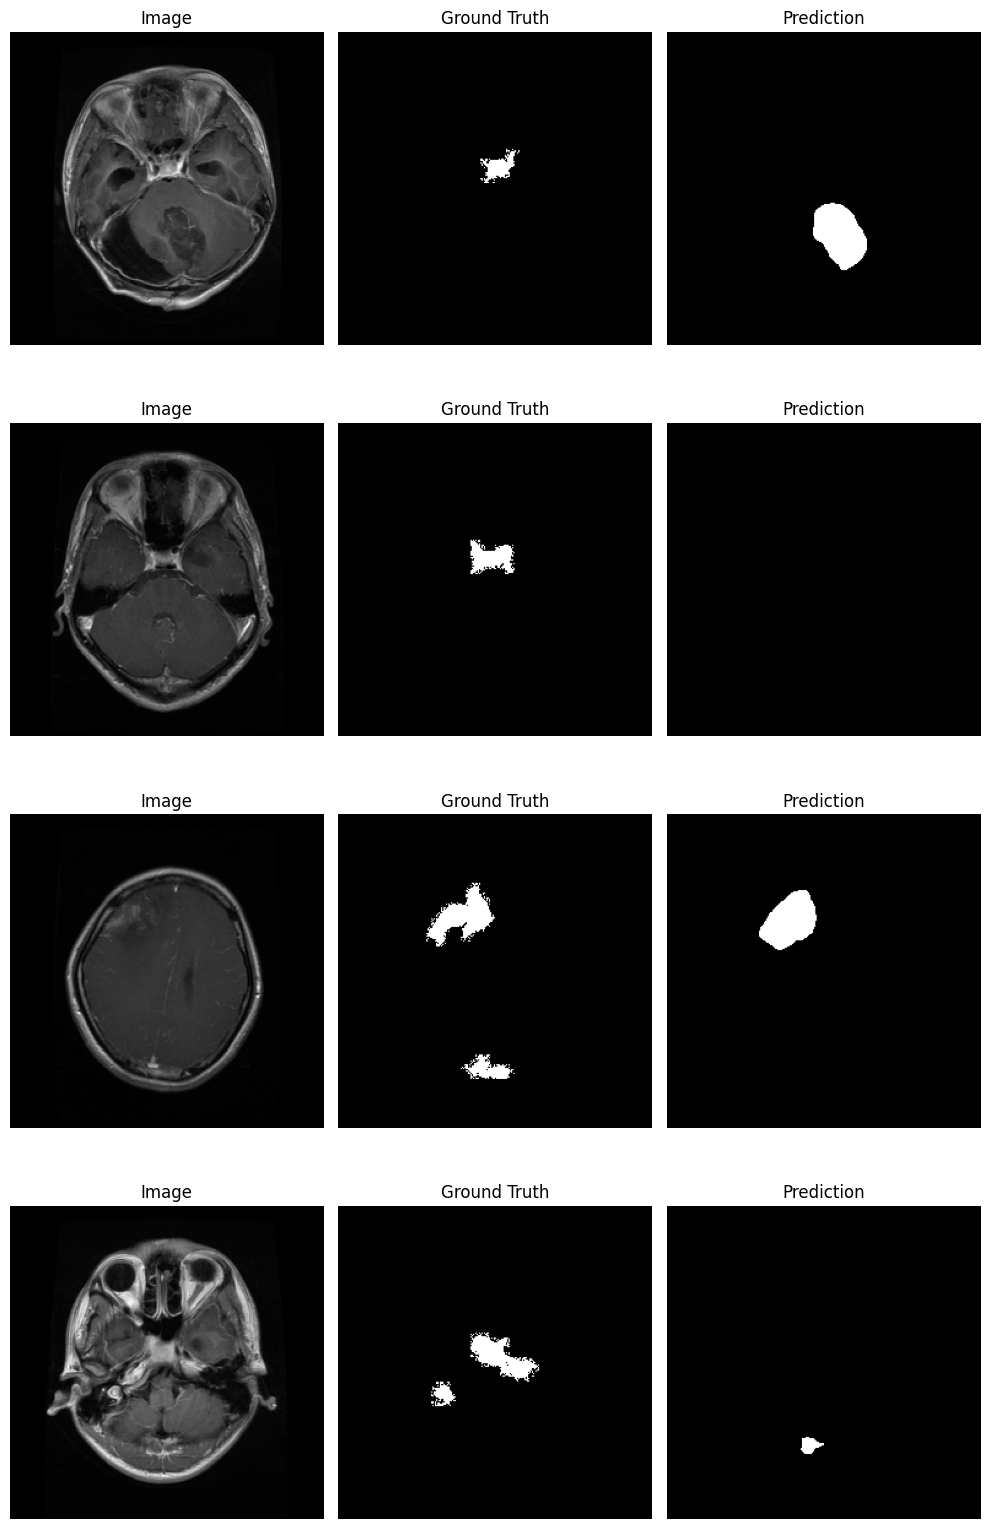

In [ ]:
# 17) Vizualizáció
@torch.no_grad()
def visualize_predictions(model, dataset, device, n=4):
    n = min(n, len(dataset))
    fig, axes = plt.subplots(n, 3, figsize=(10, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    model.eval()

    for i in range(n):
        image, mask = dataset[i]
        logits = model(image.unsqueeze(0).to(device))
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

        image_np = image.squeeze(0).cpu().numpy()
        mask_np = mask.cpu().numpy()

        axes[i, 0].imshow(image_np, cmap="gray")
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title("Prediction")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_ds, cfg.device, n=cfg.num_visualizations)
